In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
img = cv2.imread("../dataset/maria_sharapova/img1.jpg")
img

array([[[226, 224, 223],
        [226, 224, 223],
        [226, 224, 223],
        ...,
        [226, 224, 223],
        [226, 224, 223],
        [226, 224, 223]],

       [[226, 224, 223],
        [226, 224, 223],
        [226, 224, 223],
        ...,
        [226, 224, 223],
        [226, 224, 223],
        [226, 224, 223]],

       [[226, 224, 223],
        [226, 224, 223],
        [226, 224, 223],
        ...,
        [226, 224, 223],
        [226, 224, 223],
        [226, 224, 223]],

       ...,

       [[243, 255, 255],
        [243, 255, 255],
        [243, 255, 255],
        ...,
        [253, 255, 255],
        [253, 255, 255],
        [253, 255, 255]],

       [[243, 255, 255],
        [243, 255, 255],
        [243, 255, 255],
        ...,
        [253, 255, 255],
        [253, 255, 255],
        [253, 255, 255]],

       [[243, 255, 255],
        [243, 255, 255],
        [243, 255, 255],
        ...,
        [253, 255, 255],
        [253, 255, 255],
        [253, 255, 255]]

In [3]:
img.shape  #third dimension denotes rgb color here

(415, 413, 3)

In [4]:
import os
path = r"..\dataset\img1.jpg"
print(f"Does file exist? {os.path.exists(path)}")

Does file exist? False


In [5]:
import os
path = r"..\dataset"
print(f"Does file exist? {os.path.exists(path)}")

Does file exist? True


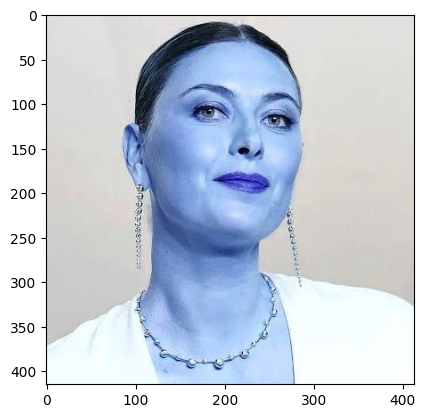

In [6]:
plt.imshow(img)

In [7]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray.shape   #the third dimension of color has been removed

(415, 413)

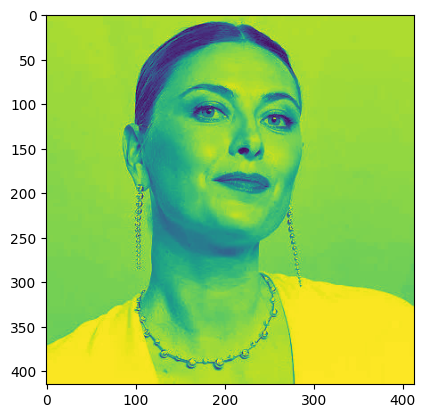

In [8]:
plt.imshow(gray)

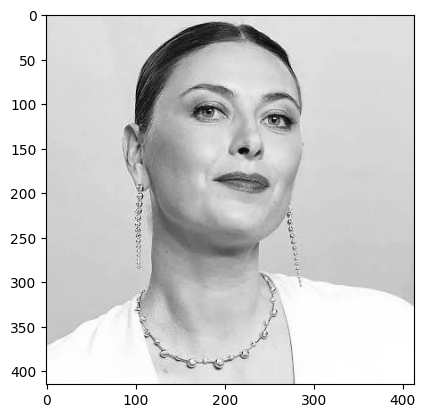

In [9]:
plt.imshow(gray, cmap='grey')

In [10]:
face_cascade = cv2.CascadeClassifier('../opencv/haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier('../opencv/haarcascade_eye.xml')

faces =face_cascade.detectMultiScale(gray, 1.3,5)
faces

array([[117,  35, 204, 204]])

In [11]:
(x,y, w,h) = faces[0]
x,y,w,h

(117, 35, 204, 204)

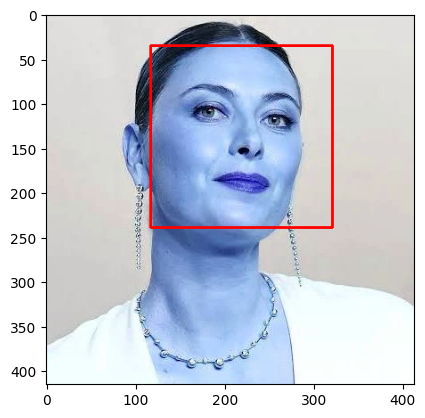

In [12]:
face_img =cv2.rectangle(img, (x,y), (x+w, y+h),(255,0,0), 2)
plt.imshow(face_img)

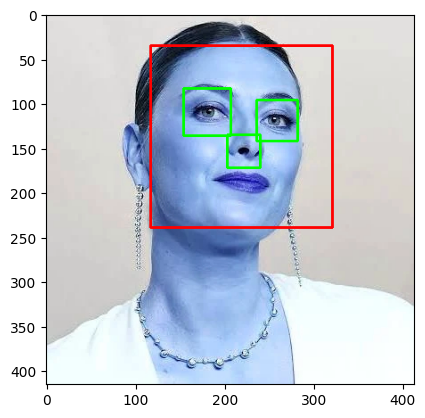

In [13]:
cv2.destroyAllWindows()

for (x,y,w,h) in faces:
    face_img =cv2.rectangle(img, (x,y), (x+w, y+h),(255,0,0), 2)
    roi_gray = gray[y:y+h, x:x+w]
    roi_color = face_img[y:y+h, x:x+w]
    eyes = eye_cascade.detectMultiScale(roi_gray)
    
    for (ex,ey,ew,eh) in eyes:
        cv2.rectangle(roi_color, (ex,ey), (ex+ew, ey+eh), (0,255,0),2)
    
plt.figure()
plt.imshow(face_img, cmap='gray')
plt.show()

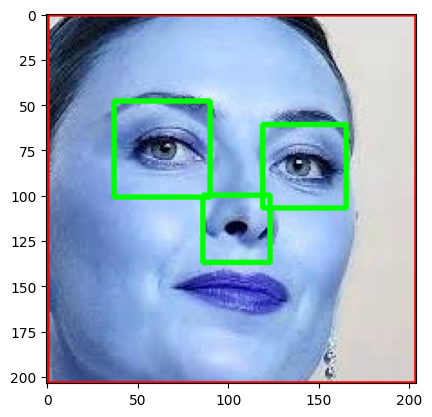

In [14]:
plt.imshow(roi_color)

In [15]:
def get_cropped_img_if_2_eyes(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3,5)
    
    for (x,y,w,h) in faces:
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = img[y:y+h, x:x+w]
        eyes = eye_cascade.detectMultiScale(roi_gray)
        if len(eyes)>=2:
            return roi_color
        

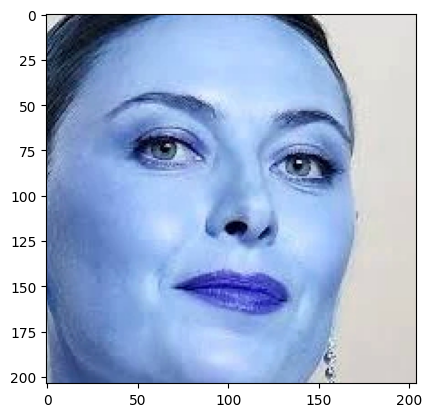

In [17]:
cropped_img = get_cropped_img_if_2_eyes('../dataset/maria_sharapova/img1.jpg')
plt.imshow(cropped_img)

In [18]:
path_to_data = "../dataset/"
path_to_cropped = '../dataset/cropped/'

In [19]:
import os
img_dir = []
for entry in os.scandir(path_to_data):
    if entry.is_dir():
        img_dir.append(entry.path)

In [20]:
img_dir

['../dataset/cropped',
 '../dataset/maria_sharapova',
 '../dataset/rohit_sharma',
 '../dataset/ronaldo']

In [21]:
import shutil
if os.path.exists(path_to_data):
    shutil.rmtree(path_to_cropped)
os.mkdir(path_to_cropped)

In [23]:
cropped_img_dir = []
celebrity_file_names_dict = {}

for img_d in img_dir:
    count = 1
    celeb_name = img_d.split('/')[-1]
    print(celeb_name)
    
    celebrity_file_names_dict[celeb_name]= []
    
    for entry in os.scandir(img_d):
        print()
        roi_color = get_cropped_img_if_2_eyes(entry.path)
        
        if roi_color is not None:
            cropped_dir = path_to_cropped + celeb_name
            
            if not os.path.exists(cropped_dir):
                os.makedirs(cropped_dir)
                
                cropped_img_dir.append(cropped_dir)
                print("generating cropped folder and images", cropped_dir)
                
            cropped_file_name = celeb_name+str(count)+'.png'
            cropped_file_path = cropped_dir+'/'+cropped_file_name
            
            cv2.imwrite(cropped_file_path, roi_color)
            celebrity_file_names_dict[celeb_name].append(cropped_file_path)
            count+=1

cropped
maria_sharapova







generating cropped folder and images ../dataset/cropped/maria_sharapova


rohit_sharma


generating cropped folder and images ../dataset/cropped/rohit_sharma

















ronaldo

generating cropped folder and images ../dataset/cropped/ronaldo











error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


In [24]:
import os

# 1. Clear the cropped folder once BEFORE the loop starts
if os.path.exists(path_to_cropped):
    shutil.rmtree(path_to_cropped)
os.makedirs(path_to_cropped)

celebrity_file_names_dict = {}

for img_d in img_dir:
    # Skip the 'cropped' folder itself if it's in your img_dir list
    celeb_name = img_d.split('/')[-1]
    if celeb_name == 'cropped':
        continue
        
    celebrity_file_names_dict[celeb_name] = []
    # Reset count for EACH celebrity
    count = 1 
    
    # Create the specific celebrity subdirectory once
    target_dir = os.path.join(path_to_cropped, celeb_name)
    if not os.path.exists(target_dir):
        os.makedirs(target_dir)

    for entry in os.scandir(img_d):
        roi_color = get_cropped_img_if_2_eyes(entry.path)
        
        if roi_color is not None:
            # Create a unique filename using the count
            cropped_file_name = f"{celeb_name}{count}.png"
            cropped_file_path = os.path.join(target_dir, cropped_file_name)
            
            cv2.imwrite(cropped_file_path, roi_color)
            celebrity_file_names_dict[celeb_name].append(cropped_file_path)
            count += 1

error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


In [25]:
# wavelet transformation 
import pywt

def w2d(img, mode='haar', level=1):
    imArray = img
    
#     datatype conversion
#     convert to grayscale
    imArray = cv2.cvtColor(imArray, cv2.COLOR_RGB2GRAY)
#     convert to float
    imArray = np.float32(imArray)
    imArray/= 255
#     compute coefficients
    coeffs = pywt.wavedec2(imArray, mode, level=level)
    
#     process coefficients
    coeffs_H = list(coeffs)
    coeffs_H[0]*=0
    
#     reconstructioabsn
    imArray_H = pywt.waverec2(coeffs_H, mode)
    imArray_H*=255
    imArray_H = np.uint8(imArray_H)
    
    return imArray_H

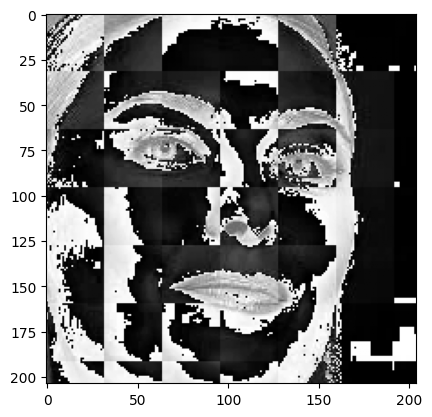

In [26]:
im_har = w2d(cropped_img, 'db1', 5)
plt.imshow(im_har, cmap='gray')

In [27]:
# assign some 
class_dict ={}
count=0
for celeb_name in celebrity_file_names_dict.keys():
    class_dict[celeb_name] = count
    count+=1
class_dict

{'maria_sharapova': 0, 'rohit_sharma': 1, 'ronaldo': 2}

In [28]:
X = []
y = []
for celebrity_name, training_files in celebrity_file_names_dict.items():
    for training_image in training_files:
        img = cv2.imread(training_image)
        scalled_raw_img = cv2.resize(img,( 32,32))
        img_har= w2d(img, 'db1', 5)
        scalled_img_har = cv2.resize(img_har, (32,32))
        combined_img = np.vstack((scalled_raw_img.reshape(32*32*3,1), scalled_img_har.reshape(32*32,1)))
        X.append(combined_img)
        y.append(class_dict[celebrity_name])

In [29]:
len(X[0])

4096

In [30]:
X = np.array(X).reshape(len(X), 4096).astype(float)
X.shape

(14, 4096)

In [31]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=0)

In [33]:
pipe = Pipeline([('scaler', StandardScaler()), ('svc', SVC(kernel='rbf', C=1))])
pipe.fit(X_train, y_train)
pipe.score(X_test, y_test)

1.0

In [34]:
print(classification_report(y_test, pipe.predict(X_test)))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [36]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

In [48]:
model_params = {
    'svm' : {
        'model': SVC(gamma='auto', probability=True),
        'params':{
            'svc__C' : [1,10,100,1000],
            'svc__kernel': ['rbf', 'linear']
        }
    },
    'random-forest':{
        'model': RandomForestClassifier(),
        'params':{
            'randomforestclassifier__n_estimators': [1,5,10]
        }
    },
    'LR': {
        'model':LogisticRegression(),
        'params':{
            'logisticregression__C': [1,5,10]
        }
    }
}

In [49]:
import pandas as pd
from sklearn.pipeline import make_pipeline

In [52]:
# grid search cv automatically divide X_train in training, validation set

scores = []
best_estimators = {}

for algo, mp in model_params.items():
    pipe = make_pipeline(StandardScaler(),mp['model'])
    clf = GridSearchCV(pipe, mp['params'], cv=5, return_train_score=False)
    clf.fit(X_train, y_train)
    scores.append({
        'model': algo,
        'best score': clf.best_score_,
        'best params': clf.best_params_
    })
    best_estimators[algo] = clf.best_estimator_

df = pd.DataFrame(scores, columns=['model', 'best score', "best params"])

C:\Users\pc\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:700: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\pc\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:700: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\pc\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:700: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


In [53]:
df

,model,best score,best params
0,svm,0.9,"{'svc__C': 1, 'svc__kernel': 'linear'}"
1,random-forest,0.8,{'randomforestclassifier__n_estimators': 5}
2,LR,0.9,{'logisticregression__C': 1}


In [54]:
# let's use validation test

best_estimators['svm']

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc',
                 SVC(C=1, gamma='auto', kernel='linear', probability=True))])

In [55]:

best_estimators['svm'].score(X_test, y_test)

0.75

In [58]:
best_estimators['random-forest'].score(X_test, y_test)

0.5

In [59]:
best_estimators['LR'].score(X_test, y_test)

0.75

In [60]:
best_clf = best_estimators['svm']

In [62]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, best_clf.predict(X_test))
cm

array([[1, 1],
       [0, 2]], dtype=int64)

Text(95.72222222222221, 0.5, 'TRUE')

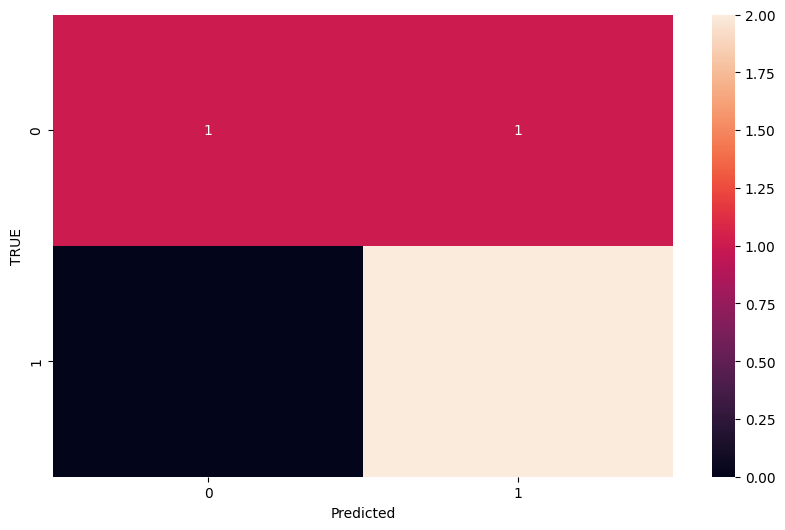

In [65]:
import seaborn as sns
plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True)
plt.xlabel("Predicted")
plt.ylabel("TRUE")

In [66]:
class_dict

{'maria_sharapova': 0, 'rohit_sharma': 1, 'ronaldo': 2}

In [67]:
# to save the model
import joblib

joblib.dump(best_clf, 'save_img_model.pkl')

['save_img_model.pkl']

In [68]:
# importing classes are also important to get the idea of what we need to do in web application

import json
with open("class_dict.json", 'w') as f:
    f.write(json.dumps(class_dict))